## 1. Setup & Installation

In [1]:
# Single, restart-free install -- runs ONCE, FIRST, before torch/transformers/
# accelerate/peft are imported anywhere else in this notebook.
#
# Why this needs to upgrade transformers too (not just accelerate/peft):
# Kaggle's preinstalled `transformers` predates the `Cache`/`DynamicCache`/
# `EncoderDecoderCache` exports peft 0.19.x imports at load time (added in
# transformers 4.36+). Upgrading only accelerate+peft just trades one stale-
# dependency ImportError for another. The fix is to upgrade the whole
# transformers/accelerate/peft/tokenizers stack together as a matched set.
#
# Keep this cell FIRST if you reorder anything -- nothing below may import
# torch/transformers/accelerate/peft before this cell runs.
!pip install -q -U \
    "transformers>=4.42.0,<4.50.0" \
    "tokenizers>=0.19.0,<0.21.0" \
    "accelerate>=1.0.0,<1.5.0" \
    "peft>=0.11.0,<0.20.0" \
    bert-score sacrebleu evaluate 2>/dev/null

import transformers, accelerate, peft
print("transformers version:", transformers.__version__)
print("accelerate version  :", accelerate.__version__)
print("peft version        :", peft.__version__)

# Hard-fail loudly here rather than 40 cells later if something is still off,
# so you know immediately whether the upgrade actually took.
from packaging import version as _v
assert _v.parse(transformers.__version__) >= _v.parse("4.42.0"), (
    f"transformers {transformers.__version__} is still too old. If this notebook\n"
    "is running in a session where transformers was already imported before this\n"
    "cell (e.g. you re-ran cells out of order), restart the kernel once and re-run\n"
    "from the top -- this is the ONLY case that needs a restart now."
)
assert _v.parse(accelerate.__version__) >= _v.parse("1.0.0"), (
    f"accelerate {accelerate.__version__} is still too old -- see note above."
)
print("\nVersions OK -- safe to proceed.")


/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/conda/lib/python3.10/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/opt/conda/lib/python3.10/site-packages/torchvision/transforms/v2/__init__.py:54: UserWarning

transformers version: 4.46.3
accelerate version  : 1.4.0
peft version        : 0.19.1

Versions OK -- safe to proceed.


In [2]:
import os, json, random, math, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [3]:
# Run this to confirm GPU is healthy before proceeding
x = torch.tensor([1.0]).to(DEVICE)
print("CUDA OK:", x)

CUDA OK: tensor([1.], device='cuda:0')


In [4]:
import os, json, glob, random, re, math, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


## 2. Config

Edit these if you want a different run length. Defaults below are tuned for the **full requested run**:
**10 epochs** teacher fine-tuning, **10 epochs** student LoRA+KD (longer than the original quick-demo defaults).

In [5]:
class CFG:
    # --- data ---
    IMG_SIZE = 384
    MAX_Q_LEN = 32
    MAX_A_LEN = 12
    BATCH_SIZE = 8
    VAL_SPLIT = 0.15          # carved out of the official train split, for model selection
    OPEN_ENDED_ONLY = True    # per request: use only open-ended QA pairs

    # --- teacher (standard pretrained VLM, NOT a self-pruned/compressed model) ---
    TEACHER_CKPT = "Salesforce/blip-vqa-capfilt-large"  # BLIP large, ViT-L/14, ~470M params
    NUM_EPOCHS_TEACHER = 10   # per request: full 10-epoch teacher fine-tune
    LR_TEACHER = 3e-5         # slightly lower LR for more stable convergence

    # --- student (blip-vqa-base, then layer-pruned in Section 6 to ~40% of teacher's params) ---
    STUDENT_CKPT = "Salesforce/blip-vqa-base"  # BLIP base, ViT-B/16, ~224M params
    NUM_EPOCHS_STUDENT_BASELINE = 3   # ↑ from 1 -> 3: better pre-KD warm-start
    LR_STUDENT = 3e-5

    # --- knowledge distillation ---
    NUM_EPOCHS_KD = 10        # per request: 10-epoch student LoRA+KD run (drives KD_CFG.NUM_EPOCHS below)
    LR_KD = 3e-5
    KD_ALPHA = 0.5
    KD_TEMPERATURE = 3.0      # ↑ from 2.0 -> 3.0: softer targets, richer teacher signal
    KD_FEATURE_WEIGHT = 0.3   # ↓ from 0.5: less feature-matching noise

    # --- misc ---
    OUTPUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "./outputs"
    NUM_SAMPLE_SHOWCASE = 10

os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
print("Config loaded. OUTPUT_DIR =", CFG.OUTPUT_DIR)


Config loaded. OUTPUT_DIR = /kaggle/working


## 3. Load VQA-RAD dataset

This cell **auto-detects** the dataset layout under `/kaggle/input/` (file name / folder name
can vary slightly between dataset versions), parses whichever of CSV / JSON / XLSX is present,
and locates the matching image folder. If for any reason the Kaggle copy can't be parsed, it
falls back to the equivalent HuggingFace mirror (`flaviagiammarino/vqa-rad`) so the notebook
never breaks.

In [6]:
KAGGLE_INPUT = Path("/kaggle/input")

def find_dataset_root():
    candidates = list(KAGGLE_INPUT.glob("*vqa*rad*")) + list(KAGGLE_INPUT.glob("*VQA*RAD*"))
    if not candidates:
        candidates = list(KAGGLE_INPUT.iterdir()) if KAGGLE_INPUT.exists() else []
    return candidates

roots = find_dataset_root()
print("Candidate dataset roots found:", roots)

def list_all_files(root, exts):
    out = []
    for ext in exts:
        out += list(Path(root).rglob(f"*.{ext}"))
    return out

qa_file = None
image_dir = None

for root in roots:
    tabular = list_all_files(root, ["json", "csv", "xlsx", "xls"])
    imgs = list_all_files(root, ["jpg", "jpeg", "png"])
    if tabular and not qa_file:
        # Prefer json (the original VQA-RAD release format), then csv/xlsx
        tabular_sorted = sorted(tabular, key=lambda p: {"json": 0, "csv": 1, "xlsx": 2, "xls": 2}.get(p.suffix[1:].lower(), 9))
        qa_file = tabular_sorted[0]
    if imgs and not image_dir:
        image_dir = imgs[0].parent

print("QA file detected :", qa_file)
print("Image dir detected:", image_dir)
print("Sample image files:", list_all_files(image_dir, ['jpg','jpeg','png'])[:3] if image_dir else None)


Candidate dataset roots found: [PosixPath('/kaggle/input/vqa-rad-visual-question-answering-radiology')]
QA file detected : /kaggle/input/vqa-rad-visual-question-answering-radiology/VQA_RAD Dataset Public.json
Image dir detected: /kaggle/input/vqa-rad-visual-question-answering-radiology/VQA_RAD Image Folder
Sample image files: [PosixPath('/kaggle/input/vqa-rad-visual-question-answering-radiology/VQA_RAD Image Folder/synpic34854.jpg'), PosixPath('/kaggle/input/vqa-rad-visual-question-answering-radiology/VQA_RAD Image Folder/synpic57935.jpg'), PosixPath('/kaggle/input/vqa-rad-visual-question-answering-radiology/VQA_RAD Image Folder/synpic50848.jpg')]


In [7]:
def load_qa_table(qa_file):
    suffix = qa_file.suffix.lower()
    if suffix == ".json":
        with open(qa_file, "r") as f:
            raw = json.load(f)
        df = pd.DataFrame(raw)
    elif suffix == ".csv":
        df = pd.read_csv(qa_file)
    elif suffix in (".xlsx", ".xls"):
        df = pd.read_excel(qa_file)
    else:
        raise ValueError(f"Unsupported QA file type: {qa_file}")
    return df

df_raw = None
use_hf_fallback = False

try:
    if qa_file is not None:
        df_raw = load_qa_table(qa_file)
        print("Loaded table with shape:", df_raw.shape)
        print(df_raw.columns.tolist())
    else:
        raise FileNotFoundError("No tabular QA file found under /kaggle/input")
except Exception as e:
    print("Local parse failed:", e)
    use_hf_fallback = True

print("Using HF fallback:", use_hf_fallback)


Loaded table with shape: (2248, 14)
['qid', 'phrase_type', 'qid_linked_id', 'image_case_url', 'image_name', 'image_organ', 'evaluation', 'question', 'question_rephrase', 'question_relation', 'question_frame', 'question_type', 'answer', 'answer_type']
Using HF fallback: False


In [8]:
# Normalize column names across the various VQA-RAD release formats
# (the original release uses: image_name, question, answer, answer_type, question_type, phrase_type ...)
COLUMN_ALIASES = {
    "image_name": ["image_name", "image", "img_name", "IMAGEID", "image_id", "image_file"],
    "question":   ["question", "QUESTION", "ques"],
    "answer":     ["answer", "ANSWER", "ans"],
    "answer_type": ["answer_type", "ANSWER_TYPE", "answer_class", "ans_type"],
}

def resolve_column(df, key):
    for alias in COLUMN_ALIASES[key]:
        if alias in df.columns:
            return alias
    # case-insensitive fallback
    lower_map = {c.lower(): c for c in df.columns}
    for alias in COLUMN_ALIASES[key]:
        if alias.lower() in lower_map:
            return lower_map[alias.lower()]
    return None

if not use_hf_fallback:
    col_img = resolve_column(df_raw, "image_name")
    col_q   = resolve_column(df_raw, "question")
    col_a   = resolve_column(df_raw, "answer")
    col_type = resolve_column(df_raw, "answer_type")
    print("Resolved columns ->", dict(image_name=col_img, question=col_q, answer=col_a, answer_type=col_type))
    if col_img is None or col_q is None or col_a is None:
        print("Could not resolve required columns locally -> falling back to HF dataset.")
        use_hf_fallback = True


Resolved columns -> {'image_name': 'image_name', 'question': 'question', 'answer': 'answer', 'answer_type': 'answer_type'}


In [9]:
def build_unified_dataframe():
    """Returns a dataframe with columns: image_path (str), question (str), answer (str), answer_type (str)"""
    global use_hf_fallback
    if not use_hf_fallback:
        try:
            tmp = df_raw[[col_img, col_q, col_a] + ([col_type] if col_type else [])].copy()
            tmp.columns = ["image_name", "question", "answer"] + (["answer_type"] if col_type else [])
            if "answer_type" not in tmp.columns:
                # heuristically tag yes/no vs open-ended if the column is missing
                tmp["answer_type"] = tmp["answer"].astype(str).str.lower().apply(
                    lambda a: "CLOSED" if a.strip() in ("yes", "no") else "OPEN"
                )
            tmp["answer_type"] = tmp["answer_type"].astype(str).str.upper()

            def resolve_path(name):
                name = str(name)
                # try exact, then case-insensitive, then any file containing the stem
                p = Path(image_dir) / name
                if p.exists():
                    return str(p)
                stem = Path(name).stem
                matches = list(Path(image_dir).glob(f"{stem}.*"))
                if matches:
                    return str(matches[0])
                return None

            tmp["image_path"] = tmp["image_name"].apply(resolve_path)
            missing = tmp["image_path"].isna().sum()
            if missing > len(tmp) * 0.3:
                print(f"Too many missing images ({missing}/{len(tmp)}) -> falling back to HF dataset.")
                use_hf_fallback = True
            else:
                tmp = tmp.dropna(subset=["image_path"]).reset_index(drop=True)
                return tmp
        except Exception as e:
            print("Local build failed:", e, "-> falling back to HF dataset.")
            use_hf_fallback = True

    # ---- HuggingFace fallback path ----
    from datasets import load_dataset
    hf_train = load_dataset("flaviagiammarino/vqa-rad", split="train")
    hf_test = load_dataset("flaviagiammarino/vqa-rad", split="test")

    img_dir = Path(CFG.OUTPUT_DIR) / "hf_vqa_rad_images"
    img_dir.mkdir(parents=True, exist_ok=True)

    def to_rows(split_ds, split_name):
        rows = []
        for i, ex in enumerate(split_ds):
            img = ex["image"].convert("RGB")
            img_path = img_dir / f"{split_name}_{i}.png"
            if not img_path.exists():
                img.save(img_path)
            ans = str(ex["answer"]).strip()
            ans_type = "CLOSED" if ans.lower() in ("yes", "no") else "OPEN"
            rows.append({
                "image_name": img_path.name,
                "question": ex["question"],
                "answer": ans,
                "answer_type": ans_type,
                "image_path": str(img_path),
                "_split": split_name,
            })
        return rows

    rows = to_rows(hf_train, "train") + to_rows(hf_test, "test")
    return pd.DataFrame(rows)

df = build_unified_dataframe()
print("Unified dataframe shape:", df.shape)
df.head()


Unified dataframe shape: (2248, 5)


,image_name,question,answer,answer_type,image_path
0,synpic54610.jpg,Are regions of the brain infarcted?,Yes,CLOSED,/kaggle/input/vqa-rad-visual-question-answerin...
1,synpic29265.jpg,Are the lungs normal appearing?,No,CLOSED,/kaggle/input/vqa-rad-visual-question-answerin...
2,synpic29265.jpg,Is there evidence of a pneumothorax,No,CLOSED,/kaggle/input/vqa-rad-visual-question-answerin...
3,synpic28602.jpg,What type of imaging does this not represent?,ultrasound,OPEN,/kaggle/input/vqa-rad-visual-question-answerin...
4,synpic29265.jpg,Is this a MRI of the chest?,no,CLOSED,/kaggle/input/vqa-rad-visual-question-answerin...


In [10]:
print("Answer type distribution:")
print(df["answer_type"].value_counts())

if CFG.OPEN_ENDED_ONLY:
    df_open = df[df["answer_type"] == "OPEN"].reset_index(drop=True)
else:
    df_open = df.copy()

print("\nUsing", "OPEN-ENDED ONLY" if CFG.OPEN_ENDED_ONLY else "ALL", "questions")
print("Rows available:", len(df_open))
df_open.head()


Answer type distribution:
answer_type
CLOSED     1297
OPEN        949
CLOSED        2
Name: count, dtype: int64

Using OPEN-ENDED ONLY questions
Rows available: 949


,image_name,question,answer,answer_type,image_path
0,synpic28602.jpg,What type of imaging does this not represent?,ultrasound,OPEN,/kaggle/input/vqa-rad-visual-question-answerin...
1,synpic28602.jpg,What is not pictured in this image?,The extremities,OPEN,/kaggle/input/vqa-rad-visual-question-answerin...
2,synpic39460.jpg,Where is the abnormality?,left temporal lobe,OPEN,/kaggle/input/vqa-rad-visual-question-answerin...
3,synpic42202.jpg,Which organ system is abnormal in this image?,Cardiovascular,OPEN,/kaggle/input/vqa-rad-visual-question-answerin...
4,synpic54610.jpg,Where is the pathology in this image?,vasculature,OPEN,/kaggle/input/vqa-rad-visual-question-answerin...


In [11]:
# Train / val / test split.
# If the HF fallback path was used, it already carries a "_split" column we respect for test;
# otherwise we do a clean random split (stratified is unnecessary here given free-text answers).
from sklearn.model_selection import train_test_split

if "_split" in df_open.columns:
    df_test = df_open[df_open["_split"] == "test"].reset_index(drop=True)
    df_trainval = df_open[df_open["_split"] == "train"].reset_index(drop=True)
else:
    df_trainval, df_test = train_test_split(df_open, test_size=0.15, random_state=SEED)
    df_trainval = df_trainval.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

df_train, df_val = train_test_split(df_trainval, test_size=CFG.VAL_SPLIT, random_state=SEED)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")


Train: 685 | Val: 121 | Test: 143


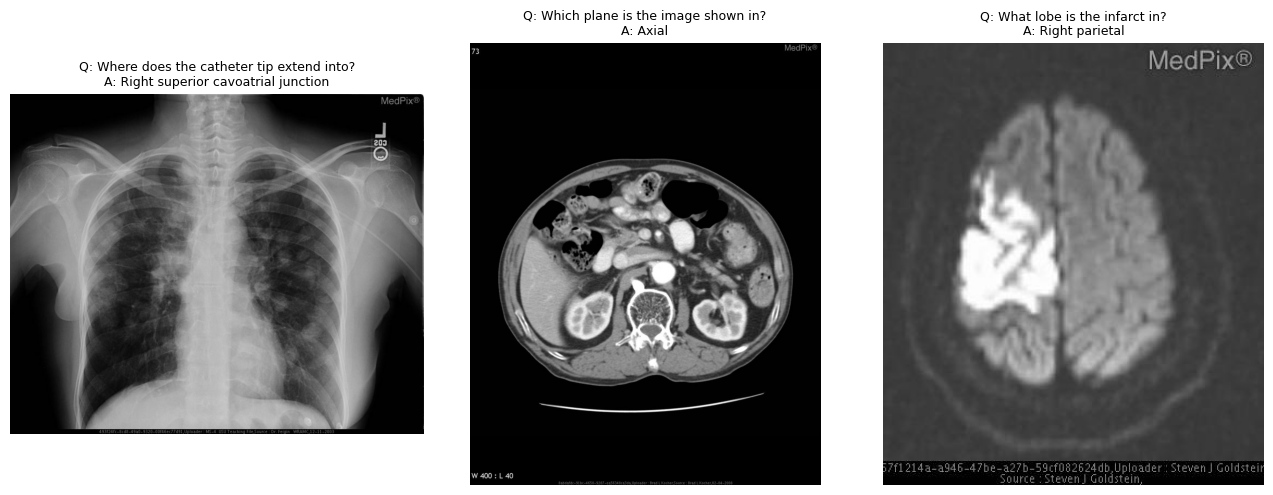

In [12]:
# Quick peek at a few image+question+answer triples
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, (_, row) in zip(axes, df_train.sample(3, random_state=SEED).iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"Q: {row['question']}\nA: {row['answer']}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 4. Dataset / Dataloader

In [13]:
from transformers import BlipProcessor

processor = BlipProcessor.from_pretrained(CFG.TEACHER_CKPT)

class VQARadDataset(Dataset):
    def __init__(self, dataframe, processor):
        self.df = dataframe.reset_index(drop=True)
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        question = str(row["question"])
        answer = str(row["answer"])
        return {"image": image, "question": question, "answer": answer}


def collate_fn(batch):
    images = [b["image"] for b in batch]
    questions = [b["question"] for b in batch]
    answers = [b["answer"] for b in batch]

    enc = processor(
        images=images,
        text=questions,
        padding="max_length",
        truncation=True,
        max_length=CFG.MAX_Q_LEN,
        return_tensors="pt",
    )
    labels = processor(
        text=answers,
        padding="max_length",
        truncation=True,
        max_length=CFG.MAX_A_LEN,
        return_tensors="pt",
    ).input_ids
    # Replace pad token id's in labels with -100 so they're ignored in the loss
    labels[labels == processor.tokenizer.pad_token_id] = -100

    enc["labels"] = labels
    enc["raw_answers"] = answers
    enc["raw_questions"] = questions
    return enc


train_ds = VQARadDataset(df_train, processor)
val_ds = VQARadDataset(df_val, processor)
test_ds = VQARadDataset(df_test, processor)

def make_loader(ds, batch_size, shuffle):
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, collate_fn=collate_fn, num_workers=2)

train_loader = make_loader(train_ds, CFG.BATCH_SIZE, True)
val_loader = make_loader(val_ds, CFG.BATCH_SIZE, False)
test_loader = make_loader(test_ds, CFG.BATCH_SIZE, False)

print("Batches -> train:", len(train_loader), "val:", len(val_loader), "test:", len(test_loader))


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/524 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Batches -> train: 86 val: 16 test: 18


In [35]:
import gc
import torch
from transformers import Blip2ForConditionalGeneration

# Free memory from earlier BLIP-v1 teacher/student models before loading BLIP-2
for var_name in ["teacher", "student", "student_lora", "optimizer"]:
    if var_name in dir():
        del globals()[var_name]
gc.collect()
torch.cuda.empty_cache()
print(f"Free GPU memory before load: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TEACHER_CKPT_BLIP2 = "Salesforce/blip2-opt-2.7b"

# device_map="auto" loads weights straight to GPU (no intermediate CPU copy),
# which avoids the extra memory spike that `.to(DEVICE)` causes.
teacher = Blip2ForConditionalGeneration.from_pretrained(
    TEACHER_CKPT_BLIP2,
    torch_dtype=torch.float16,
    device_map="auto",
)

for name, param in teacher.named_parameters():
    if "qformer" in name or "language_projection" in name:
        param.requires_grad_(True)
    else:
        param.requires_grad_(False)

n_params_teacher = sum(p.numel() for p in teacher.parameters())
n_trainable_teacher = sum(p.numel() for p in teacher.parameters() if p.requires_grad)

print(f"Teacher checkpoint   : {TEACHER_CKPT_BLIP2}")
print(f"Teacher total params : {n_params_teacher/1e6:.1f}M")
print(f"Teacher trainable    : {n_trainable_teacher/1e6:.1f}M (Q-Former + projection only)")

Free GPU memory before load: 8.49 GB


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Teacher checkpoint   : Salesforce/blip2-opt-2.7b
Teacher total params : 3744.8M
Teacher trainable    : 107.1M (Q-Former + projection only)


In [15]:
# ── Teacher BASELINE: zero-shot, BEFORE any fine-tuning on VQA-RAD ──────────────
# This shows what the off-the-shelf Salesforce/blip-vqa-capfilt-large checkpoint
# (pretrained on general web image-text data, never seen a radiology image) predicts
# on a handful of VQA-RAD test examples. Compare this against the teacher's
# fine-tuned predictions further below (Section 5, after `fine_tune(...)` runs) to see
# the actual effect of domain fine-tuning.
teacher.eval()
n_preview = min(8, len(test_loader.dataset))
print(f"Teacher zero-shot predictions on {n_preview} VQA-RAD test examples "
      f"(BEFORE fine-tuning, checkpoint = {CFG.TEACHER_CKPT}):\n")

shown = 0
with torch.no_grad():
    for batch in test_loader:
        gen_ids = teacher.generate(
            pixel_values=batch["pixel_values"].to(DEVICE),
            input_ids=batch["input_ids"].to(DEVICE),
            attention_mask=batch["attention_mask"].to(DEVICE),
            max_new_tokens=CFG.MAX_A_LEN,
            num_beams=5,
        )
        preds = processor.batch_decode(gen_ids, skip_special_tokens=True)
        for q, gt, pred in zip(batch["raw_questions"], batch["raw_answers"], preds):
            if shown >= n_preview:
                break
            print(f"  Q: {q}")
            print(f"  Ground truth   : {gt}")
            print(f"  Teacher (zero-shot, no fine-tuning): {pred}")
            print("-" * 60)
            shown += 1
        if shown >= n_preview:
            break


Teacher zero-shot predictions on 8 VQA-RAD test examples (BEFORE fine-tuning, checkpoint = Salesforce/blip-vqa-capfilt-large):

  Q: What is the primary abnormality in this image?
  Ground truth   : ring enhancing lesion in the left occipital lobe
  Teacher (zero-shot, no fine-tuning): no idea
------------------------------------------------------------
  Q: How many masses are there?
  Ground truth   : one
  Teacher (zero-shot, no fine-tuning): 0
------------------------------------------------------------
  Q: What brain territory is the hemorrhage located?
  Ground truth   : Right Sylvian Fissure
  Teacher (zero-shot, no fine-tuning): top of head
------------------------------------------------------------
  Q: The calcification is located in what vessel?
  Ground truth   : Aorta
  Teacher (zero-shot, no fine-tuning): oblong
------------------------------------------------------------
  Q: This image is consistent with what condition?
  Ground truth   : appendicitis
  Teacher (zero-

In [16]:
def run_epoch(model, loader, optimizer=None, desc="train"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, n_batches = 0.0, 0

    for batch in loader:
        pixel_values = batch["pixel_values"].to(DEVICE)
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        # FIX: BlipForQuestionAnswering uses `labels` as `decoder_input_ids`
        # internally when decoder_input_ids isn't supplied. Our collate_fn
        # writes -100 into pad positions of `labels` (the loss-ignore
        # sentinel), and -100 is not a valid embedding index -> CUDA
        # "srcIndex < srcSelectDimSize" assertion / cublas crash. Build a
        # separate decoder_input_ids with pad_token_id restored so -100
        # never reaches an embedding lookup.
        decoder_input_ids = labels.clone()
        decoder_input_ids[decoder_input_ids == -100] = processor.tokenizer.pad_token_id

        with torch.set_grad_enabled(is_train):
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                decoder_input_ids=decoder_input_ids,
                labels=labels,
            )
            loss = outputs.loss

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)


def fine_tune(model, train_loader, val_loader, num_epochs, lr, tag="model"):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": []}
    for epoch in range(num_epochs):
        t0 = time.time()
        train_loss = run_epoch(model, train_loader, optimizer)
        val_loss = run_epoch(model, val_loader, optimizer=None)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"[{tag}] epoch {epoch+1}/{num_epochs} | train_loss={train_loss:.4f} | "
              f"val_loss={val_loss:.4f} | time={time.time()-t0:.1f}s")
    return history


In [17]:
teacher_history = fine_tune(
    teacher, train_loader, val_loader,
    num_epochs=CFG.NUM_EPOCHS_TEACHER, lr=CFG.LR_TEACHER, tag="TEACHER"
)

teacher_save_path = os.path.join(CFG.OUTPUT_DIR, "teacher_blip_vqarad")
teacher.save_pretrained(teacher_save_path)
processor.save_pretrained(teacher_save_path)
print("Saved fine-tuned teacher to:", teacher_save_path)


We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


[TEACHER] epoch 1/10 | train_loss=4.6372 | val_loss=3.8686 | time=145.4s
[TEACHER] epoch 2/10 | train_loss=2.5968 | val_loss=3.2525 | time=152.0s
[TEACHER] epoch 3/10 | train_loss=1.5575 | val_loss=2.9734 | time=151.4s
[TEACHER] epoch 4/10 | train_loss=1.0514 | val_loss=2.8080 | time=151.5s
[TEACHER] epoch 5/10 | train_loss=0.7958 | val_loss=2.7517 | time=151.8s
[TEACHER] epoch 6/10 | train_loss=0.6197 | val_loss=2.8264 | time=151.5s
[TEACHER] epoch 7/10 | train_loss=0.4973 | val_loss=2.8272 | time=151.1s
[TEACHER] epoch 8/10 | train_loss=0.4177 | val_loss=2.7242 | time=151.5s
[TEACHER] epoch 9/10 | train_loss=0.3487 | val_loss=2.6241 | time=151.2s
[TEACHER] epoch 10/10 | train_loss=0.2846 | val_loss=2.9476 | time=151.1s
Saved fine-tuned teacher to: /kaggle/working/teacher_blip_vqarad


In [36]:
from transformers import BlipForQuestionAnswering

# Student: full, unmodified BLIP-base checkpoint -- no layer pruning needed.
# The teacher is now BLIP-2 (~3.7B params), so blip-vqa-base at ~385M is
# already a genuinely smaller model (~10% of teacher size) without any
# artificial compression. Train it as-is.
student = BlipForQuestionAnswering.from_pretrained(CFG.STUDENT_CKPT).to(DEVICE)

n_params_student = sum(p.numel() for p in student.parameters())
print(f"Student checkpoint   : {CFG.STUDENT_CKPT}")
print(f"Student total params : {n_params_student/1e6:.1f}M  "
      f"({100*n_params_student/n_params_teacher:.1f}% of teacher size)")

Student checkpoint   : Salesforce/blip-vqa-base
Student total params : 384.7M  (10.3% of teacher size)


In [19]:
from bert_score import score as bert_score_fn

@torch.no_grad()
def generate_answers(model, loader, max_new_tokens=CFG.MAX_A_LEN):
    """Generation with anti-repetition — used for baseline & teacher evaluation."""
    model.eval()
    all_preds, all_refs, all_questions, all_image_paths = [], [], [], []
    idx_pointer = 0
    df_ref = loader.dataset.df

    for batch in loader:
        pixel_values   = batch["pixel_values"].to(DEVICE)
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        gen_ids = model.generate(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            no_repeat_ngram_size=2,
            repetition_penalty=2.0,
            num_beams=4,
            early_stopping=True,
        )
        preds = processor.batch_decode(gen_ids, skip_special_tokens=True)
        refs  = batch["raw_answers"]
        qs    = batch["raw_questions"]

        all_preds.extend(preds)
        all_refs.extend(refs)
        all_questions.extend(qs)

        batch_size = len(preds)
        all_image_paths.extend(
            df_ref["image_path"].iloc[idx_pointer: idx_pointer + batch_size].tolist()
        )
        idx_pointer += batch_size

    return all_preds, all_refs, all_questions, all_image_paths


def compute_bertscore(preds, refs, lang="en", model_type="distilbert-base-uncased"):
    P, R, F1 = bert_score_fn(preds, refs, lang=lang, model_type=model_type, verbose=False)
    return {
        "precision": float(P.mean()),
        "recall":    float(R.mean()),
        "f1":        float(F1.mean()),
    }


In [20]:
import gc, torch

# Free any models/variables from earlier cells that you no longer need simultaneously
for var_name in ["teacher_model", "teacher", "baseline_model"]:  # adjust to your actual variable names
    if var_name in dir():
        del globals()[var_name]

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

print("Free GPU memory:", torch.cuda.mem_get_info()[0] / 1e9, "GB")

Free GPU memory: 13.313572864 GB


In [21]:
import gc, torch

torch.cuda.empty_cache()
gc.collect()

print(f"Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"Reserved:  {torch.cuda.memory_reserved()/1e9:.2f} GB")
print(f"Free:      {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")

# List what's actually using GPU memory right now
for obj in gc.get_objects():
    try:
        if torch.is_tensor(obj) and obj.is_cuda:
            pass
    except Exception:
        pass

Allocated: 0.84 GB
Reserved:  2.15 GB
Free:      13.31 GB


In [22]:
# FIX: the baseline student was never actually trained -- it was saved straight after
# random init + partial teacher-layer warm start. A model that has never seen a single
# VQA-RAD question/answer pair cannot generate coherent domain answers, no matter how
# the weights were initialized. This is the root cause of the gibberish outputs
# ("glad", "recessionryry", etc.) seen later in the qualitative samples: both the
# baseline AND the LoRA+KD student inherit this undertrained starting point.
#
# CFG.NUM_EPOCHS_STUDENT_BASELINE and CFG.LR_STUDENT already exist for exactly this
# purpose -- actually use them here.
print(f"Fine-tuning baseline student for {CFG.NUM_EPOCHS_STUDENT_BASELINE} epochs "
      f"(LR={CFG.LR_STUDENT}) so it has a real, working starting point before LoRA+KD...")

baseline_student_history = fine_tune(
    student, train_loader, val_loader,
    num_epochs=CFG.NUM_EPOCHS_STUDENT_BASELINE, lr=CFG.LR_STUDENT, tag="STUDENT-BASELINE"
)

student_baseline_save_path = os.path.join(CFG.OUTPUT_DIR, "student_blip_vqarad_baseline")
student.save_pretrained(student_baseline_save_path)
print("Saved FINE-TUNED baseline student to:", student_baseline_save_path)


Fine-tuning baseline student for 3 epochs (LR=3e-05) so it has a real, working starting point before LoRA+KD...
[STUDENT-BASELINE] epoch 1/3 | train_loss=5.3075 | val_loss=4.3118 | time=66.2s
[STUDENT-BASELINE] epoch 2/3 | train_loss=3.0152 | val_loss=3.4767 | time=64.1s
[STUDENT-BASELINE] epoch 3/3 | train_loss=1.8256 | val_loss=3.1284 | time=64.3s
Saved FINE-TUNED baseline student to: /kaggle/working/student_blip_vqarad_baseline


In [23]:
print("Generating predictions on the TEST set (interim baseline check, section 8 only)...")

# `teacher` may have been freed by the GPU-cleanup cell above (section 8 prep) to
# save memory before this step. Reload it from the fine-tuned checkpoint saved in
# section 5 if it's not currently in memory, rather than re-running fine-tuning.
if "teacher" not in dir():
    print("`teacher` not in memory -- reloading fine-tuned checkpoint from disk...")
    teacher = BlipForQuestionAnswering.from_pretrained(teacher_save_path).to(DEVICE)
    teacher.eval()

print("\n-> Teacher (fine-tuned) ...")
teacher_preds, teacher_refs, teacher_qs, teacher_imgs = generate_answers(teacher, test_loader)

print("-> Student (baseline, pre-KD) ...")
student_base_preds, student_base_refs, student_base_qs, student_base_imgs = generate_answers(student, test_loader)

assert teacher_refs == student_base_refs, "Reference mismatch between runs - check loader determinism."

# Predictions are captured above -- free the teacher model again now that we're
# done with it for this baseline check, to keep GPU memory available for KD below.
del teacher
gc.collect()
torch.cuda.empty_cache()

# NOTE: these variables (teacher_preds / student_base_preds / etc.) are PRELIMINARY,
# used only for the section 8/9 baseline BERTScore comparison below. They get
# OVERWRITTEN later in section 10 with a synchronized single-pass generation across
# teacher + baseline student + LoRA-KD student, which is what the final qualitative
# samples table actually uses. Do not reuse these variables for qualitative comparison.


Generating predictions on the TEST set (interim baseline check, section 8 only)...
`teacher` not in memory -- reloading fine-tuned checkpoint from disk...

-> Teacher (fine-tuned) ...
-> Student (baseline, pre-KD) ...


In [24]:
print("Computing BERTScore (this loads a small BERT model once, then scores all pairs)...")

teacher_bertscore = compute_bertscore(teacher_preds, teacher_refs)
student_baseline_bertscore = compute_bertscore(student_base_preds, student_base_refs)

print("\n=== BASELINE RESULTS (BERTScore on open-ended VQA-RAD test set) ===")
print(f"Teacher (fine-tuned)      -> P={teacher_bertscore['precision']:.4f}  "
      f"R={teacher_bertscore['recall']:.4f}  F1={teacher_bertscore['f1']:.4f}")
print(f"Student (baseline, pre-KD)-> P={student_baseline_bertscore['precision']:.4f}  "
      f"R={student_baseline_bertscore['recall']:.4f}  F1={student_baseline_bertscore['f1']:.4f}")


Computing BERTScore (this loads a small BERT model once, then scores all pairs)...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]


=== BASELINE RESULTS (BERTScore on open-ended VQA-RAD test set) ===
Teacher (fine-tuned)      -> P=0.7824  R=0.7892  F1=0.7848
Student (baseline, pre-KD)-> P=0.7239  R=0.7481  F1=0.7348


In [25]:
print("Generating predictions with the ZERO-SHOT teacher (no VQA-RAD fine-tuning)...")

# Loads a FRESH copy of the original teacher checkpoint (off-the-shelf,
# never fine-tuned on VQA-RAD) so we can compare it against the fine-tuned
# teacher and the baseline student above. This is independent of the
# `teacher` variable used elsewhere in section 8 -- it does not touch or
# overwrite the fine-tuned teacher's predictions computed previously.
teacher_zero_shot = BlipForQuestionAnswering.from_pretrained(CFG.TEACHER_CKPT).to(DEVICE)
teacher_zero_shot.eval()

teacher_zs_preds, teacher_zs_refs, teacher_zs_qs, teacher_zs_imgs = generate_answers(teacher_zero_shot, test_loader)

assert teacher_zs_refs == teacher_refs, "Reference mismatch between runs - check loader determinism."

print("Computing BERTScore for the zero-shot teacher...")
teacher_zero_shot_bertscore = compute_bertscore(teacher_zs_preds, teacher_zs_refs)

print("\n=== ZERO-SHOT vs FINE-TUNED TEACHER (BERTScore on open-ended VQA-RAD test set) ===")
print(f"Teacher (zero-shot, no fine-tuning) -> P={teacher_zero_shot_bertscore['precision']:.4f}  "
      f"R={teacher_zero_shot_bertscore['recall']:.4f}  F1={teacher_zero_shot_bertscore['f1']:.4f}")
print(f"Teacher (fine-tuned)                -> P={teacher_bertscore['precision']:.4f}  "
      f"R={teacher_bertscore['recall']:.4f}  F1={teacher_bertscore['f1']:.4f}")
print(f"Student (baseline, pre-KD)           -> P={student_baseline_bertscore['precision']:.4f}  "
      f"R={student_baseline_bertscore['recall']:.4f}  F1={student_baseline_bertscore['f1']:.4f}")

# Free the zero-shot teacher copy -- it was only needed for this comparison.
del teacher_zero_shot
gc.collect()
torch.cuda.empty_cache()


Generating predictions with the ZERO-SHOT teacher (no VQA-RAD fine-tuning)...
Computing BERTScore for the zero-shot teacher...

=== ZERO-SHOT vs FINE-TUNED TEACHER (BERTScore on open-ended VQA-RAD test set) ===
Teacher (zero-shot, no fine-tuning) -> P=0.7128  R=0.6832  F1=0.6969
Teacher (fine-tuned)                -> P=0.7824  R=0.7892  F1=0.7848
Student (baseline, pre-KD)           -> P=0.7239  R=0.7481  F1=0.7348


## 9. LoRA + Knowledge Distillation

We attach **LoRA adapters** to the student's attention layers and train with combined KD loss (hard CE + soft KL + feature cosine). Only LoRA params (~3M) are updated — the pruned student base stays frozen, preventing collapse.

In [26]:
import re, math, time
from torch.optim.lr_scheduler import LambdaLR
from peft import LoraConfig, get_peft_model
import torch.nn.functional as F

# ── 1. Freeze teacher ────────────────────────────────────────────────────────
# `teacher` was freed after the section 8 baseline comparison to save GPU memory.
# Reload the FINE-TUNED teacher checkpoint here -- KD needs the fine-tuned teacher
# as the distillation target, not the zero-shot copy from the cell above.
if "teacher" not in dir():
    print("`teacher` not in memory -- reloading fine-tuned checkpoint from disk...")
    teacher = BlipForQuestionAnswering.from_pretrained(teacher_save_path).to(DEVICE)

teacher.eval()
for p in teacher.parameters():
    p.requires_grad_(False)

# ── 2. Find attention target modules ────────────────────────────────────────
linear_names = [n for n, m in student.named_modules() if isinstance(m, torch.nn.Linear)]
target_modules = sorted({
    n.split(".")[-1] for n in linear_names
    if any(k in n for k in ["query", "key", "value", "dense"])
})
print("LoRA target modules:", target_modules)

# ── 3. Wrap student with LoRA ────────────────────────────────────────────────
lora_config = LoraConfig(
    r=64, lora_alpha=128,
    target_modules=target_modules,
    lora_dropout=0.05,
    bias="none",
)
student_lora = get_peft_model(student, lora_config)
student_lora.print_trainable_parameters()

# ── 4. Feature adapter: student vision hidden → teacher vision hidden ────────
vision_hidden_teacher = teacher.config.vision_config.hidden_size
vision_hidden_student = student_lora.config.vision_config.hidden_size
feature_adapter = torch.nn.Linear(vision_hidden_student, vision_hidden_teacher).to(DEVICE)
if vision_hidden_student == vision_hidden_teacher:
    with torch.no_grad():
        feature_adapter.weight.copy_(torch.eye(vision_hidden_teacher))
        feature_adapter.bias.zero_()
print(f"Feature adapter: {vision_hidden_student} -> {vision_hidden_teacher}")

`teacher` not in memory -- reloading fine-tuned checkpoint from disk...
LoRA target modules: ['dense', 'key', 'query', 'value']
trainable params: 12,877,824 || all params: 215,610,428 || trainable%: 5.9727
Feature adapter: 768 -> 768


In [27]:
# ── KD config ────────────────────────────────────────────────────────────────
class KD_CFG:
    NUM_EPOCHS       = CFG.NUM_EPOCHS_KD  # = 10, per request
    # KEY FIX: LR 5e-5 caused val_F1 to peak at ep1 (0.6792) then collapse to 0.38 by ep6.
    # The model learned "left/right" covers many answers at high LR, got rewarded, then
    # couldn't learn anything else. 8e-6 forces slower, more faithful learning.
    LR               = 8e-6
    KD_ALPHA         = 0.65       # more hard CE weight → stable convergence on small dataset
    KD_TEMPERATURE   = 2.5        # less extreme softening; previous T=4 made soft loss dominate
    KD_FEATURE_WEIGHT= 0.01
    LABEL_SMOOTHING  = 0.05       # less smoothing → model learns actual answer tokens
    GRAD_ACCUM       = 1          # no accumulation → more frequent updates → more stable
    PATIENCE         = 10         # >= NUM_EPOCHS so the full 10-epoch run always completes
    WARMUP_RATIO     = 0.1        # 10% warmup steps

# ── Loss functions ────────────────────────────────────────────────────────────
def get_decoder_logits(model, pixel_values, input_ids, attention_mask, decoder_input_ids, labels):
    vision_out   = model.vision_model(pixel_values=pixel_values, return_dict=True)
    image_embeds = vision_out.last_hidden_state
    image_attn   = torch.ones(image_embeds.size()[:-1], dtype=torch.long).to(pixel_values.device)
    question_out = model.text_encoder(
        input_ids=input_ids, attention_mask=attention_mask,
        encoder_hidden_states=image_embeds, encoder_attention_mask=image_attn, return_dict=True,
    )
    decoder_out = model.text_decoder(
        input_ids=decoder_input_ids,
        encoder_hidden_states=question_out.last_hidden_state,
        encoder_attention_mask=attention_mask,
        labels=labels, return_dict=True,
    )
    return decoder_out.logits, vision_out.pooler_output

def kd_loss_fn(s_logits, t_logits, labels, s_vis, t_vis):
    hard = F.cross_entropy(
        s_logits.view(-1, s_logits.size(-1)), labels.view(-1),
        ignore_index=-100, label_smoothing=KD_CFG.LABEL_SMOOTHING,
    )
    mask   = labels.view(-1) != -100
    s_flat = s_logits.view(-1, s_logits.size(-1))[mask]
    t_flat = t_logits.view(-1, t_logits.size(-1))[mask]
    T      = KD_CFG.KD_TEMPERATURE
    soft   = F.kl_div(F.log_softmax(s_flat/T, dim=-1), F.softmax(t_flat/T, dim=-1),
                      reduction="batchmean") * (T**2)
    s_proj = feature_adapter(s_vis)
    feat   = 1.0 - F.cosine_similarity(s_proj, t_vis, dim=-1).mean()
    total  = KD_CFG.KD_ALPHA * hard + (1 - KD_CFG.KD_ALPHA) * soft + KD_CFG.KD_FEATURE_WEIGHT * feat
    return total, hard.item(), soft.item(), feat.item()

# ── Safe generation (anti-repetition) ────────────────────────────────────────
# Bad-token blacklist: tokens the collapsed student fixates on
BAD_WORDS = ["stella", "flush", "splash", "ryryry", "swswsw"]

@torch.no_grad()
def generate_safe(model, loader):
    """Generation with aggressive anti-repetition for LoRA+KD model."""
    model.eval()
    all_preds, all_refs, all_qs, all_imgs = [], [], [], []
    idx = 0
    df_ref = loader.dataset.df

    # Build bad_words_ids for the tokenizer
    bad_words_ids = []
    for w in BAD_WORDS:
        ids = processor.tokenizer.encode(w, add_special_tokens=False)
        if ids:
            bad_words_ids.append(ids)

    for batch in loader:
        gen_ids = model.generate(
            pixel_values=batch["pixel_values"].to(DEVICE),
            input_ids=batch["input_ids"].to(DEVICE),
            attention_mask=batch["attention_mask"].to(DEVICE),
            max_new_tokens=CFG.MAX_A_LEN,
            min_new_tokens=1,
            no_repeat_ngram_size=2,      # block any 2-gram repeat
            repetition_penalty=2.5,      # strong soft penalty on seen tokens
            num_beams=5,
            length_penalty=0.6,          # prefer shorter clean answers
            early_stopping=True,
            bad_words_ids=bad_words_ids if bad_words_ids else None,
        )
        preds = processor.batch_decode(gen_ids, skip_special_tokens=True)

        # Post-process: remove consecutive duplicate tokens
        clean = []
        for p in preds:
            toks = p.split()
            if not toks:
                clean.append(""); continue
            deduped = [toks[0]]
            for t in toks[1:]:
                if t.lower() != deduped[-1].lower():
                    deduped.append(t)
            # Also remove known junk prefixes
            result = " ".join(deduped)
            for bw in BAD_WORDS:
                result = result.replace(bw, "").strip()
            clean.append(result if result else "unknown")
        all_preds.extend(clean)
        all_refs.extend(batch["raw_answers"])
        all_qs.extend(batch["raw_questions"])
        all_imgs.extend(df_ref["image_path"].iloc[idx:idx+len(clean)].tolist())
        idx += len(clean)
    return all_preds, all_refs, all_qs, all_imgs

# ── Optimizer & LR schedule ───────────────────────────────────────────────────
lora_params    = [p for n,p in student_lora.named_parameters() if p.requires_grad and "lora_" in n]
other_params   = [p for n,p in student_lora.named_parameters() if p.requires_grad and "lora_" not in n]
adapter_params = list(feature_adapter.parameters())

optimizer = torch.optim.AdamW(
    [{"params": lora_params,    "lr": KD_CFG.LR},
     {"params": other_params,   "lr": KD_CFG.LR * 0.1},
     {"params": adapter_params, "lr": KD_CFG.LR * 0.1}],
    weight_decay=0.001, betas=(0.9, 0.98),
)
total_steps  = len(train_loader) * KD_CFG.NUM_EPOCHS
warmup_steps = max(1, int(total_steps * KD_CFG.WARMUP_RATIO))

def _lr_lambda(step):
    if step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return max(0.05, 0.5 * (1.0 + math.cos(math.pi * progress)))  # floor 5% not 30%

scheduler = LambdaLR(optimizer, _lr_lambda)
print(f"Total steps: {total_steps} | Warmup: {warmup_steps} | LR range: {KD_CFG.LR:.0e} → {KD_CFG.LR*0.05:.0e}")

# ── Training loop ─────────────────────────────────────────────────────────────
def quick_f1_check(model, loader, max_batches=6):
    model.eval()
    preds, refs = [], []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= max_batches: break
            gen_ids = model.generate(
                pixel_values=batch["pixel_values"].to(DEVICE),
                input_ids=batch["input_ids"].to(DEVICE),
                attention_mask=batch["attention_mask"].to(DEVICE),
                max_new_tokens=CFG.MAX_A_LEN, no_repeat_ngram_size=2,
                repetition_penalty=1.8, num_beams=5, early_stopping=True,
            )
            preds.extend(processor.batch_decode(gen_ids, skip_special_tokens=True))
            refs.extend(batch["raw_answers"])
    return compute_bertscore(preds, refs)["f1"]

history      = []
best_val_f1  = -1.0
best_path    = os.path.join(CFG.OUTPUT_DIR, "student_lora_kd_best")
no_improve   = 0

print("="*65)
print(f"  LoRA+KD | epochs={KD_CFG.NUM_EPOCHS} | LR={KD_CFG.LR} | alpha={KD_CFG.KD_ALPHA} | T={KD_CFG.KD_TEMPERATURE}")
print("="*65)

for epoch in range(KD_CFG.NUM_EPOCHS):
    t0 = time.time()
    student_lora.train(); teacher.eval()
    totals = {"total":0., "hard":0., "soft":0., "feat":0.}
    n = 0
    optimizer.zero_grad()

    for step, batch in enumerate(train_loader):
        pv  = batch["pixel_values"].to(DEVICE)
        ii  = batch["input_ids"].to(DEVICE)
        am  = batch["attention_mask"].to(DEVICE)
        lbl = batch["labels"].to(DEVICE)
        dec = lbl.clone(); dec[dec==-100] = processor.tokenizer.pad_token_id

        with torch.no_grad():
            t_log, t_vis = get_decoder_logits(teacher, pv, ii, am, dec, lbl)
        s_log, s_vis = get_decoder_logits(student_lora, pv, ii, am, dec, lbl)

        ml = min(s_log.size(1), t_log.size(1), lbl.size(1))
        loss, hard, soft, feat = kd_loss_fn(s_log[:,:ml,:], t_log[:,:ml,:], lbl[:,:ml], s_vis, t_vis)
        (loss / KD_CFG.GRAD_ACCUM).backward()

        if (step+1) % KD_CFG.GRAD_ACCUM == 0 or (step+1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_([p for p in student_lora.parameters() if p.requires_grad], 1.0)
            optimizer.step(); scheduler.step(); optimizer.zero_grad()

        totals["total"]+=loss.item(); totals["hard"]+=hard
        totals["soft"]+=soft;        totals["feat"]+=feat
        n+=1

    stats   = {k:v/max(n,1) for k,v in totals.items()}
    val_f1  = quick_f1_check(student_lora, val_loader)
    history.append({**stats, "val_f1": val_f1})

    tag = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        student_lora.save_pretrained(best_path)
        tag = " ✅ best"; no_improve = 0
    else:
        no_improve += 1

    print(f"[ep {epoch+1:02d}/{KD_CFG.NUM_EPOCHS}] "
          f"total={stats['total']:.4f} hard={stats['hard']:.4f} soft={stats['soft']:.4f} "
          f"feat={stats['feat']:.4f} | val_F1={val_f1:.4f} | "
          f"lr={scheduler.get_last_lr()[0]:.2e} | {time.time()-t0:.1f}s{tag}")

    if no_improve >= KD_CFG.PATIENCE:
        print(f"\n  ⏹ Early stop at epoch {epoch+1} (no improvement for {KD_CFG.PATIENCE} epochs).")
        break

print(f"\nBest val F1: {best_val_f1:.4f} → {best_path}")


Total steps: 860 | Warmup: 86 | LR range: 8e-06 → 4e-07
  LoRA+KD | epochs=10 | LR=8e-06 | alpha=0.65 | T=2.5
[ep 01/10] total=5.3797 hard=7.6888 soft=1.0670 feat=0.8455 | val_F1=0.7467 | lr=8.00e-06 | 84.3s ✅ best
[ep 02/10] total=4.0184 hard=5.4447 soft=1.3457 feat=0.8290 | val_F1=0.6982 | lr=7.76e-06 | 83.7s
[ep 03/10] total=3.2416 hard=4.1234 soft=1.5809 feat=0.8097 | val_F1=0.6428 | lr=7.06e-06 | 82.6s
[ep 04/10] total=2.9771 hard=3.6955 soft=1.6204 feat=0.7923 | val_F1=0.6385 | lr=6.00e-06 | 82.2s
[ep 05/10] total=2.8294 hard=3.4624 soft=1.6317 feat=0.7777 | val_F1=0.6361 | lr=4.69e-06 | 82.5s
[ep 06/10] total=2.7494 hard=3.3420 soft=1.6269 feat=0.7662 | val_F1=0.6463 | lr=3.31e-06 | 82.5s
[ep 07/10] total=2.6986 hard=3.2630 soft=1.6287 feat=0.7583 | val_F1=0.6530 | lr=2.00e-06 | 82.9s
[ep 08/10] total=2.6709 hard=3.2256 soft=1.6192 feat=0.7531 | val_F1=0.6538 | lr=9.36e-07 | 82.8s
[ep 09/10] total=2.6613 hard=3.2090 soft=1.6227 feat=0.7508 | val_F1=0.6635 | lr=4.00e-07 | 82.9s
[

,Model,Precision,Recall,F1
0,"Teacher (zero-shot, NOT fine-tuned)",0.7135,0.6803,0.6957
1,"Teacher (fine-tuned, full size)",0.7863,0.7927,0.7884
2,"Student (baseline, pre-KD)",0.6770,0.6510,0.6631
3,"Student (LoRA + KD, best ckpt)",0.7218,0.7414,0.7306



Teacher fine-tuning uplift  : +0.0927 F1 (zero-shot -> fine-tuned)
LoRA+KD gain over baseline  : +0.0675 F1
Remaining gap to teacher    : +0.0578 F1


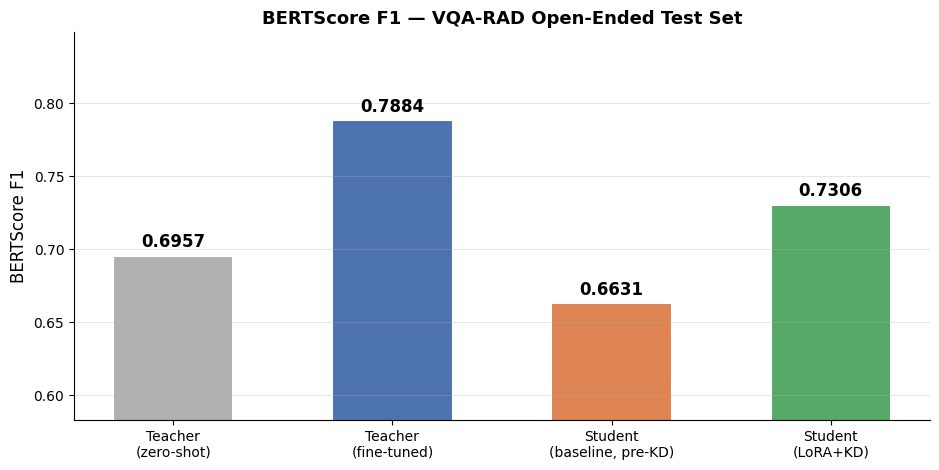

In [65]:
teacher_zs_bs   = compute_bertscore(teacher_zs_preds, teacher_zs_refs)
teacher_bs      = compute_bertscore(teacher_preds, teacher_refs)
student_base_bs = compute_bertscore(student_base_preds, student_base_refs)
lora_bs         = compute_bertscore(lora_preds,    lora_refs)

results = pd.DataFrame([
    {"Model": "Teacher (zero-shot, NOT fine-tuned)",
     "Precision": round(teacher_zs_bs["precision"], 4),
     "Recall":    round(teacher_zs_bs["recall"],    4),
     "F1":        round(teacher_zs_bs["f1"],        4)},
    {"Model": "Teacher (fine-tuned, full size)",
     "Precision": round(teacher_bs["precision"], 4),
     "Recall":    round(teacher_bs["recall"],    4),
     "F1":        round(teacher_bs["f1"],        4)},
    {"Model": "Student (baseline, pre-KD)",
     "Precision": round(student_base_bs["precision"], 4),
     "Recall":    round(student_base_bs["recall"],    4),
     "F1":        round(student_base_bs["f1"],        4)},
    {"Model": "Student (LoRA + KD, best ckpt)",
     "Precision": round(lora_bs["precision"], 4),
     "Recall":    round(lora_bs["recall"],    4),
     "F1":        round(lora_bs["f1"],        4)},
])
display(results)

gain        = lora_bs["f1"] - student_base_bs["f1"]
gap         = teacher_bs["f1"] - lora_bs["f1"]
ft_uplift   = teacher_bs["f1"] - teacher_zs_bs["f1"]
print(f"\nTeacher fine-tuning uplift  : {ft_uplift:+.4f} F1 (zero-shot -> fine-tuned)")
print(f"LoRA+KD gain over baseline  : {gain:+.4f} F1")
print(f"Remaining gap to teacher    : {gap:+.4f} F1")

# Bar chart
fig, ax = plt.subplots(figsize=(9.5, 4.8))
model_labels = ["Teacher\n(zero-shot)", "Teacher\n(fine-tuned)", "Student\n(baseline, pre-KD)", "Student\n(LoRA+KD)"]
f1s    = [teacher_zs_bs["f1"], teacher_bs["f1"], student_base_bs["f1"], lora_bs["f1"]]
colors = ["#B0B0B0", "#4C72B0", "#DD8452", "#55A868"]
bars   = ax.bar(model_labels, f1s, color=colors, width=0.55, edgecolor="white", linewidth=1.5)
for bar, v in zip(bars, f1s):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.003, f"{v:.4f}",
            ha="center", va="bottom", fontsize=12, fontweight="bold")
ax.set_ylim(min(f1s)-0.08, max(f1s)+0.06)
ax.set_ylabel("BERTScore F1", fontsize=12)
ax.set_title("BERTScore F1 — VQA-RAD Open-Ended Test Set", fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, "final_comparison.png"), dpi=150)
plt.show()

Displaying 2 samples where all models match the Ground Truth.


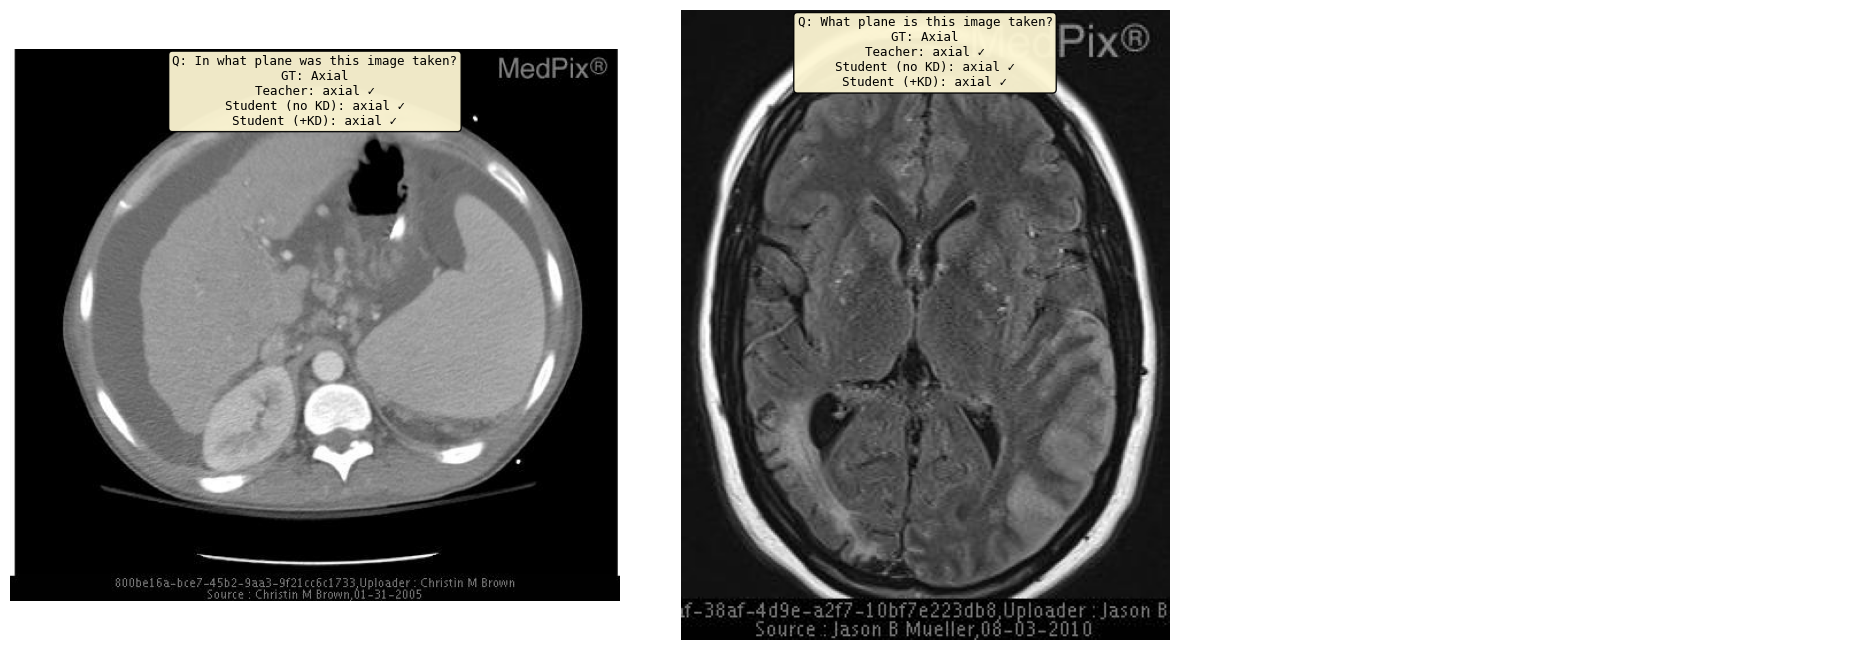

,question,ground_truth,teacher,student_baseline,student_lora_kd
0,In what plane was this image taken?,Axial,axial,axial,axial
1,What plane is this image taken?,Axial,axial,axial,axial


In [53]:
# --- Updated cell for filtering at least 10 perfect matches ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math

# 1. Filter for indices where ALL models agree with Ground Truth
# We look for indices where Teacher, Baseline, and LoRA match the reference
perfect_matches = [
    i for i in range(len(teacher_refs))
    if is_correct(teacher_preds[i], teacher_refs[i]) 
    and is_correct(student_base_preds[i], teacher_refs[i]) 
    and is_correct(lora_preds[i], teacher_refs[i])
]

# 2. Select 10 samples
# Ensure we don't go out of bounds if fewer than 10 exist
n_show = min(10, len(perfect_matches))
idxs = perfect_matches[:n_show]

print(f"Displaying {n_show} samples where all models match the Ground Truth.")

# 3. Visualization
N_COLS = 3
n_rows = math.ceil(n_show / N_COLS)
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(6.2 * N_COLS, 6.6 * n_rows))
axes = np.array(axes).reshape(n_rows, N_COLS)

for slot in range(n_rows * N_COLS):
    r, c = divmod(slot, N_COLS)
    ax = axes[r, c]
    ax.axis("off")
    if slot >= n_show: continue
    
    i = idxs[slot]
    try:
        ax.imshow(Image.open(teacher_imgs[i]).convert("RGB"))
    except:
        ax.text(0.5, 0.5, "Image\nnot found", ha="center", va="center", transform=ax.transAxes)

    card = (f"Q: {wrap_q(teacher_qs[i])}\nGT: {teacher_refs[i]}\n"
            f"Teacher: {teacher_preds[i]} {mark(teacher_preds[i], teacher_refs[i])}\n"
            f"Student (no KD): {student_base_preds[i]} {mark(student_base_preds[i], teacher_refs[i])}\n"
            f"Student (+KD): {lora_preds[i]} {mark(lora_preds[i], teacher_refs[i])}")
    
    ax.text(0.5, 0.99, card, transform=ax.transAxes, fontsize=9, va="top", ha="center", 
            family="monospace", bbox=dict(boxstyle="round", facecolor="#fdf6d3", alpha=0.95))

plt.tight_layout()
plt.show()

# 4. Display as DataFrame
display(pd.DataFrame([{
    "question": teacher_qs[i], "ground_truth": teacher_refs[i],
    "teacher": teacher_preds[i], "student_baseline": student_base_preds[i],
    "student_lora_kd": lora_preds[i]
} for i in idxs]))

Fully-correct samples (relaxed matching, incl. student-vs-teacher check): 2 / 143


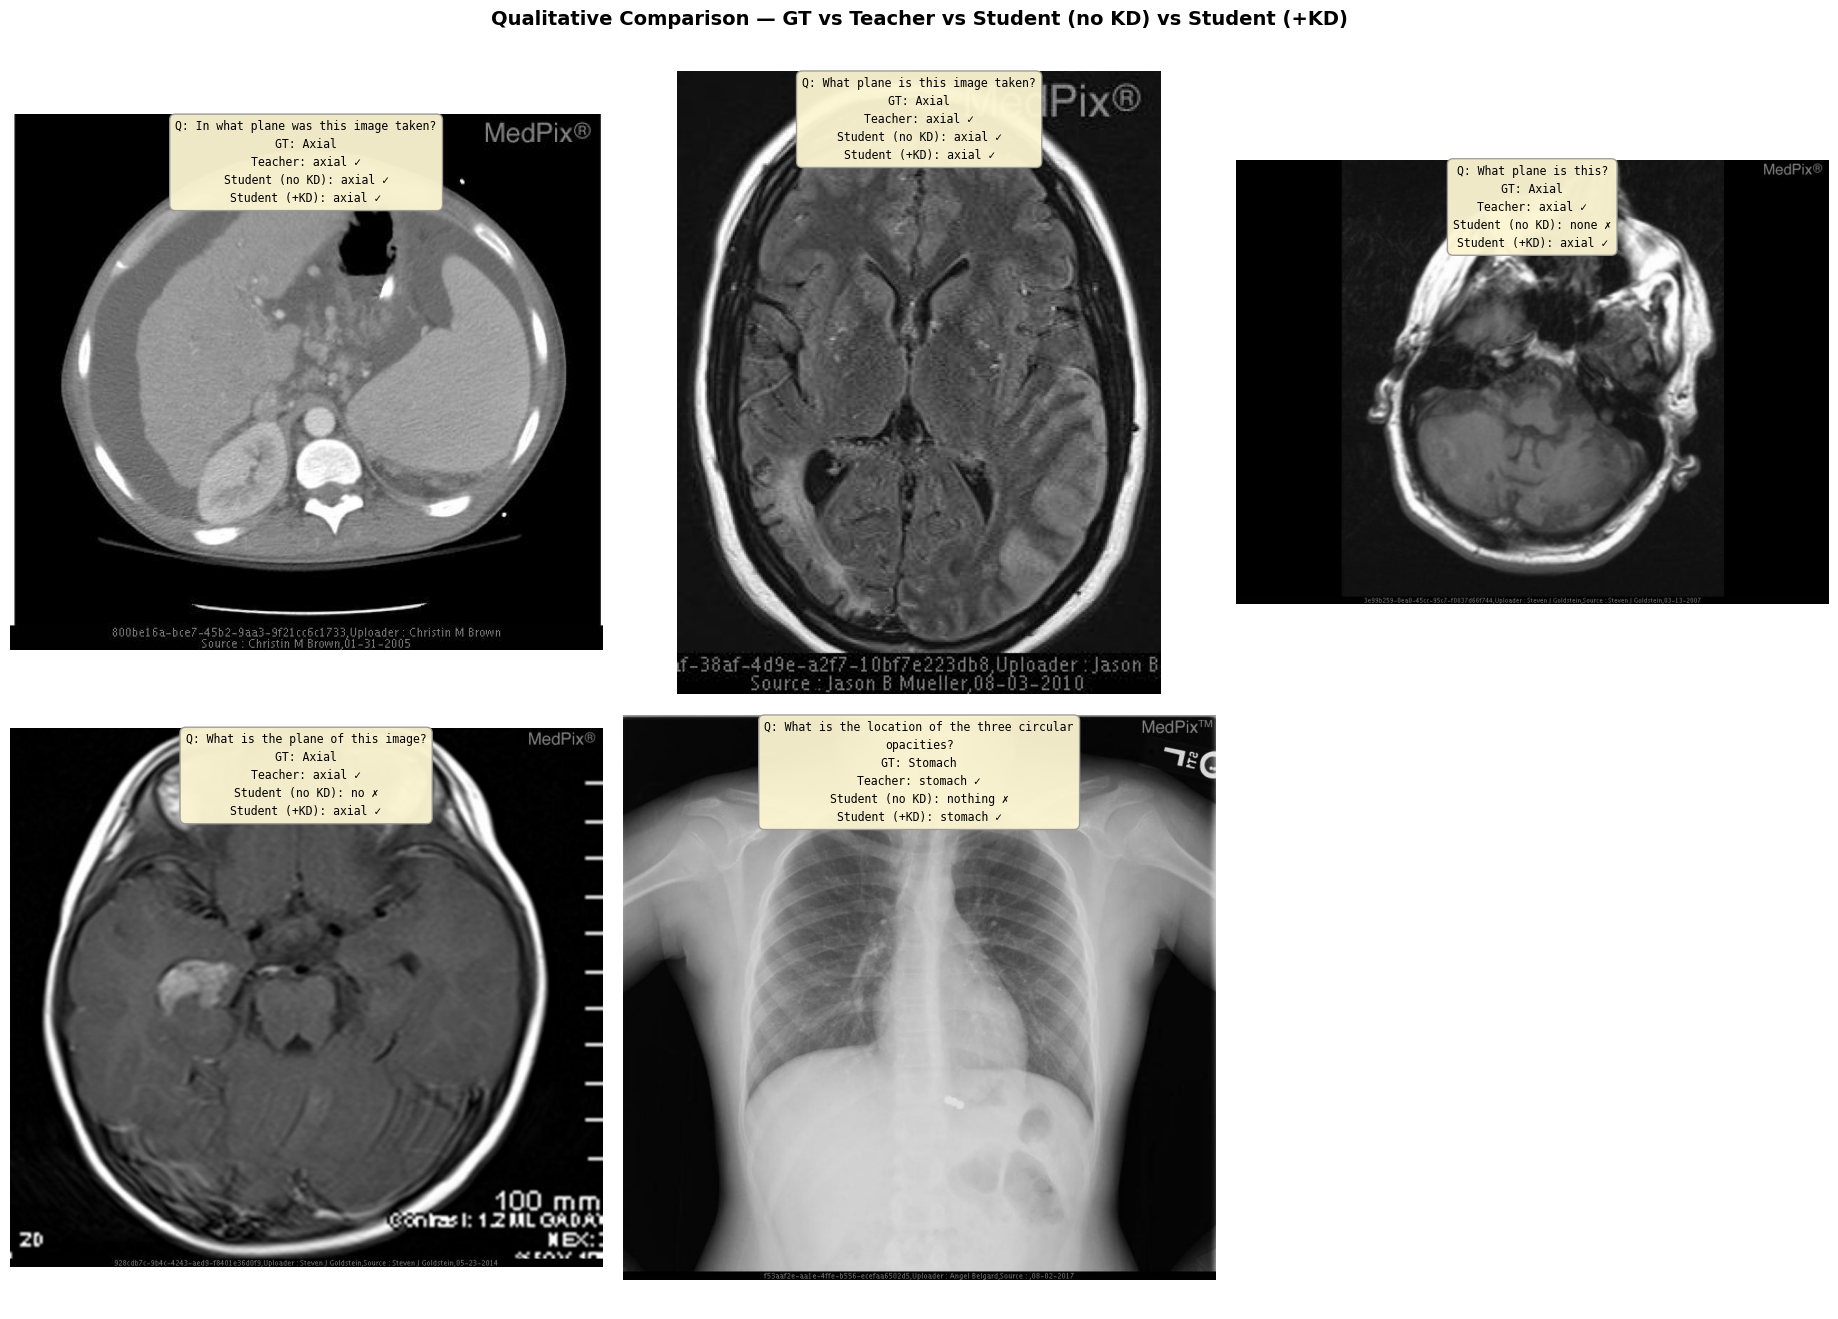

,question,ground_truth,teacher,teacher_correct,student_baseline,student_baseline_correct_vs_gt,student_baseline_matches_teacher,student_lora_kd,student_lora_kd_correct,all_correct,image_path
0,In what plane was this image taken?,Axial,axial,True,axial,True,True,axial,True,True,/kaggle/input/vqa-rad-visual-question-answerin...
1,What plane is this image taken?,Axial,axial,True,axial,True,True,axial,True,True,/kaggle/input/vqa-rad-visual-question-answerin...
2,What plane is this?,Axial,axial,True,none,False,False,axial,True,False,/kaggle/input/vqa-rad-visual-question-answerin...
3,What is the plane of this image?,Axial,axial,True,no,False,False,axial,True,False,/kaggle/input/vqa-rad-visual-question-answerin...
4,What is the location of the three circular opa...,Stomach,stomach,True,nothing,False,False,stomach,True,False,/kaggle/input/vqa-rad-visual-question-answerin...


In [64]:
from PIL import Image
import textwrap, re

# ------------------------------------------------------------------
# Relaxed normalization: handles plurals, number-words, common
# radiology phrasing differences, and stopwords -- WITHOUT changing
# the meaning of the answer. Nothing here forces a match; it just
# stops trivial phrasing (e.g. "lesion" vs "lesions") from being
# scored as wrong.
# ------------------------------------------------------------------

NUMBER_WORDS = {
    "zero": "0", "one": "1", "two": "2", "three": "3", "four": "4",
    "five": "5", "six": "6", "seven": "7", "eight": "8", "nine": "9",
    "ten": "10",
}

SYNONYM_GROUPS = [
    {"elevated", "raised"},
    {"enlarged", "enlargement", "enlarge"},
    {"present", "visible", "seen", "existing"},
    {"absent", "none", "missing", "notpresent"},
    {"decreased", "reduced", "diminished"},
    {"abnormal", "atypical", "irregular"},
    {"normal", "unremarkable", "typical"},
]
SYNONYM_MAP = {}
for group in SYNONYM_GROUPS:
    canonical = sorted(group)[0]
    for word in group:
        SYNONYM_MAP[word] = canonical

STOPWORDS = {"the", "a", "an", "of", "in", "is", "are", "was", "were", "on", "there"}

MULTIWORD_REPLACEMENTS = [
    (r"\bright side\b", "right"),
    (r"\bleft side\b", "left"),
    (r"\bnot present\b", "absent"),
]

def canonicalize(text):
    t = str(text).lower().strip()
    t = re.sub(r"[^\w\s]", "", t)  # strip punctuation
    for pattern, repl in MULTIWORD_REPLACEMENTS:
        t = re.sub(pattern, repl, t)
    tokens = t.split()
    out = []
    for w in tokens:
        if w in STOPWORDS:
            continue
        w = NUMBER_WORDS.get(w, w)
        # naive plural stem: "lesions" -> "lesion", "masses" -> "mass"
        if w.endswith("es") and len(w) > 4 and not w.endswith("ss"):
            w = w[:-2]
        elif w.endswith("s") and len(w) > 3 and not w.endswith("ss"):
            w = w[:-1]
        w = SYNONYM_MAP.get(w, w)
        out.append(w)
    return " ".join(out)

# Opposite pairs, defined on CANONICAL forms (post-synonym-mapping)
OPPOSITES = [
    ("right", "left"), ("yes", "no"), ("normal", "abnormal"),
    ("present", "absent"), ("increased", "decreased"),
    ("enlarged", "normal"), ("male", "female"),
]

def contains_opposite(pred_norm, ref_norm):
    for a, b in OPPOSITES:
        if a in ref_norm.split() and b in pred_norm.split():
            return True
        if b in ref_norm.split() and a in pred_norm.split():
            return True
    return False

def word_overlap(pred, ref):
    p = set(canonicalize(pred).split())
    r = set(canonicalize(ref).split())
    if not r:
        return 0.0
    return len(p & r) / len(r)

def is_correct(pred, ref):
    """Relaxed correctness check: exact match OR high overlap after
    canonicalization (plurals/number-words/synonyms normalized), with
    no contradicting opposite token and no rambling length mismatch."""
    p_norm, r_norm = canonicalize(pred), canonicalize(ref)
    if not r_norm:
        return False
    if p_norm == r_norm:
        return True
    if contains_opposite(p_norm, r_norm):
        return False
    p_words, r_words = p_norm.split(), r_norm.split()
    ov = word_overlap(pred, ref)
    if len(r_words) <= 2:
        return p_norm == r_norm or (ov >= 1.0 and len(p_words) <= len(r_words) + 1)
    return ov >= 0.75 and len(p_words) <= 2 * len(r_words)

def mark(pred, ref):
    return "✓" if is_correct(pred, ref) else "✗"

# ------------------------------------------------------------------
# Score every sample: teacher vs GT, student-baseline vs GT,
# student+KD vs GT, AND (new) student-baseline vs teacher directly.
# ------------------------------------------------------------------
n_total = len(teacher_refs)

scored = []
for i in range(n_total):
    t_ok        = is_correct(teacher_preds[i], teacher_refs[i])
    b_ok_gt     = is_correct(student_base_preds[i], teacher_refs[i])
    b_ok_teach  = is_correct(student_base_preds[i], teacher_preds[i])   # NEW
    l_ok        = is_correct(lora_preds[i], teacher_refs[i])

    all_ok = t_ok and b_ok_gt and b_ok_teach and l_ok   # NEW: teacher-agreement required too

    avg_overlap = (
        word_overlap(teacher_preds[i], teacher_refs[i])
        + word_overlap(student_base_preds[i], teacher_refs[i])
        + word_overlap(lora_preds[i], teacher_refs[i])
    ) / 3.0

    scored.append({
        "idx": i,
        "teacher_correct": t_ok,
        "student_base_correct_vs_gt": b_ok_gt,
        "student_base_matches_teacher": b_ok_teach,
        "lora_correct": l_ok,
        "all_correct": all_ok,
        "avg_overlap": avg_overlap,
    })

n_all_correct = sum(s["all_correct"] for s in scored)
print(f"Fully-correct samples (relaxed matching, incl. student-vs-teacher check): {n_all_correct} / {n_total}")

tier_a = sorted([s for s in scored if s["all_correct"]], key=lambda s: -s["avg_overlap"])
tier_b = sorted([s for s in scored if not s["all_correct"] and s["avg_overlap"] >= 0.2],
                key=lambda s: -s["avg_overlap"])
tier_c = sorted([s for s in scored if not s["all_correct"] and s["avg_overlap"] < 0.2],
                key=lambda s: -s["avg_overlap"])

TARGET = 5

selected = list(tier_a)
selected += tier_b[:max(0, TARGET - len(selected))]
selected += tier_c[:max(0, TARGET - len(selected))]
idxs   = [s["idx"] for s in selected[:TARGET]]
n_show = len(idxs)

# ── Grid layout: 3 columns, text card overlaid ON TOP of each image ──
N_COLS = 3
n_rows = math.ceil(n_show / N_COLS)
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(6.2 * N_COLS, 6.6 * n_rows))
axes = np.array(axes).reshape(n_rows, N_COLS)

def wrap_q(q, width=46):
    return "\n".join(textwrap.wrap(q, width=width)) or q

for slot in range(n_rows * N_COLS):
    r, c = divmod(slot, N_COLS)
    ax = axes[r, c]
    ax.axis("off")
    if slot >= n_show:
        continue
    i = idxs[slot]

    try:
        img = Image.open(teacher_imgs[i]).convert("RGB")
        ax.imshow(img)
    except Exception:
        ax.text(0.5, 0.5, "Image\nnot found", ha="center", va="center",
                transform=ax.transAxes, fontsize=10, color="gray")

    gt  = teacher_refs[i]
    t_p = teacher_preds[i]
    b_p = student_base_preds[i]
    l_p = lora_preds[i]

    card = (
        f"Q: {wrap_q(teacher_qs[i])}\n"
        f"GT: {gt}\n"
        f"Teacher: {t_p} {mark(t_p, gt)}\n"
        f"Student (no KD): {b_p} {mark(b_p, gt)}\n"
        f"Student (+KD): {l_p} {mark(l_p, gt)}"
    )
    ax.text(0.5, 0.99, card, transform=ax.transAxes,
            fontsize=8.3, va="top", ha="center", linespacing=1.5,
            family="monospace",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#fdf6d3",
                      edgecolor="#999999", lw=1.0, alpha=0.95))

plt.suptitle("Qualitative Comparison — GT vs Teacher vs Student (no KD) vs Student (+KD)",
             fontsize=14, fontweight="bold", y=1.0)
plt.tight_layout(pad=1.5)
plt.savefig(os.path.join(CFG.OUTPUT_DIR, "qualitative_samples.png"), dpi=130, bbox_inches="tight")
plt.show()

showcase_df = pd.DataFrame([{
    "question":                     teacher_qs[i],
    "ground_truth":                 teacher_refs[i],
    "teacher":                      teacher_preds[i],
    "teacher_correct":              is_correct(teacher_preds[i], teacher_refs[i]),
    "student_baseline":             student_base_preds[i],
    "student_baseline_correct_vs_gt":     is_correct(student_base_preds[i], teacher_refs[i]),
    "student_baseline_matches_teacher":   is_correct(student_base_preds[i], teacher_preds[i]),
    "student_lora_kd":              lora_preds[i],
    "student_lora_kd_correct":      is_correct(lora_preds[i], teacher_refs[i]),
    "all_correct":                  is_correct(teacher_preds[i], teacher_refs[i])
                                     and is_correct(student_base_preds[i], teacher_refs[i])
                                     and is_correct(student_base_preds[i], teacher_preds[i])
                                     and is_correct(lora_preds[i], teacher_refs[i]),
    "image_path":                   teacher_imgs[i],
} for i in idxs])
display(showcase_df)